# Seasonality

我们将探索 NeuralProphet 的季节性组件。它允许模型捕捉季节性影响，例如一周中某一天的正偏差或负偏差。

在关于趋势的实验中，我们禁用了季节性。让我们逐步启用季节性，从年度季节性开始。看看它对模型有什么影响。为简单起见，我们将保持趋势线性，且没有变化点。

WARNING - (NP.forecaster.fit) - When Global modeling with local normalization, metrics are displayed in normalized scale.
WARNING - (py.warnings._showwarnmsg) - d:\Neural_Networks\envs\timeseries\Lib\site-packages\neuralprophet\df_utils.py:1152: FutureWarning:

Series.view is deprecated and will be removed in a future version. Use ``astype`` as an alternative to change the dtype.


INFO - (NP.df_utils._infer_frequency) - Major frequency D corresponds to 99.932% of the data.
INFO - (NP.df_utils._infer_frequency) - Dataframe freq automatically defined as D
INFO - (NP.config.init_data_params) - Setting normalization to global as only one dataframe provided for training.
INFO - (NP.config.set_auto_batch_epoch) - Auto-set batch_size to 32
INFO - (NP.config.set_auto_batch_epoch) - Auto-set epochs to 100


Training: |          | 0/? [00:00<?, ?it/s]

WARNING - (NP.config.set_lr_finder_args) - Learning rate finder: The number of batches (46) is too small than the required number                     for the learning rate finder (229). The results might not be optimal.
Finding best initial lr: 100%|██████████| 229/229 [00:02<00:00, 109.09it/s]


Training: |          | 0/? [00:32<?, ?it/s, v_num=19, train_loss=0.0317, reg_loss=0.000, MAE=8.150, RMSE=10.30, Loss=0.0317, RegLoss=0.000]

WARNING - (py.warnings._showwarnmsg) - d:\Neural_Networks\envs\timeseries\Lib\site-packages\neuralprophet\df_utils.py:1152: FutureWarning:

Series.view is deprecated and will be removed in a future version. Use ``astype`` as an alternative to change the dtype.


INFO - (NP.df_utils._infer_frequency) - Major frequency D corresponds to 99.932% of the data.
WARNING - (py.warnings._showwarnmsg) - d:\Neural_Networks\envs\timeseries\Lib\site-packages\neuralprophet\df_utils.py:1152: FutureWarning:

Series.view is deprecated and will be removed in a future version. Use ``astype`` as an alternative to change the dtype.


WARNING - (py.warnings._showwarnmsg) - d:\Neural_Networks\envs\timeseries\Lib\site-packages\neuralprophet\df_utils.py:1152: FutureWarning:

Series.view is deprecated and will be removed in a future version. Use ``astype`` as an alternative to change the dtype.


INFO - (NP.df_utils._infer_frequency) - Defined frequency is equal to major frequency - D
WARNING - (py.warnings._sho


Predicting DataLoader 0: 100%|██████████| 2/2 [00:00<00:00, 286.48it/s]

INFO - (NP.df_utils.return_df_in_original_format) - Returning df with no ID column
WARNING - (py.warnings._showwarnmsg) - d:\Neural_Networks\envs\timeseries\Lib\site-packages\neuralprophet\plot_forecast_plotly.py:100: FutureWarning:

The behavior of DatetimeProperties.to_pydatetime is deprecated, in a future version this will return a Series containing python datetime objects instead of an ndarray. To retain the old behavior, call `np.array` on the result




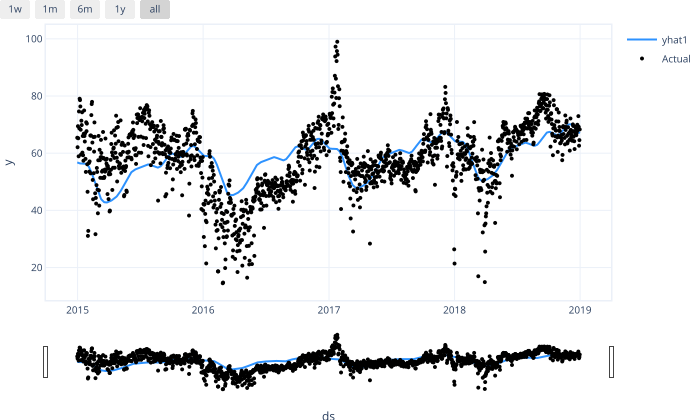

In [7]:
import pandas as pd
from neuralprophet import NeuralProphet, set_log_level

# Disable logging messages unless there is an error
# set_log_level("ERROR")

# Load the dataset from the CSV file using pandas
df = pd.read_csv('./data/SF_hospital_load.csv')

# Model and prediction with yearly seasonality
m = NeuralProphet(
    # Disable trend changepoints
    n_changepoints=0,
    # Disable seasonality components, except yearly
    yearly_seasonality=True,
    weekly_seasonality=False,
    daily_seasonality=False,
)
m.set_plotting_backend("plotly-static")
metrics = m.fit(df)
forecast = m.predict(df)
m.plot(forecast)

绘制预测的所有组成部分后，我们发现预测由趋势和年度季节性以加法方式组成。这意味着我们的预测 $\hat{y}$ 是趋势和季节性的总和：

$$\text{Prediction}(t) = \hat{y}(t) = \text{Trend}(t) + \text{Seasonality}_{yearly}(t)$$

当我们分别绘制趋势和季节性成分时，我们可以更清楚地看到这一点。

WARNING - (py.warnings._showwarnmsg) - d:\Neural_Networks\envs\timeseries\Lib\site-packages\neuralprophet\plot_forecast_plotly.py:410: FutureWarning:

The behavior of DatetimeProperties.to_pydatetime is deprecated, in a future version this will return a Series containing python datetime objects instead of an ndarray. To retain the old behavior, call `np.array` on the result




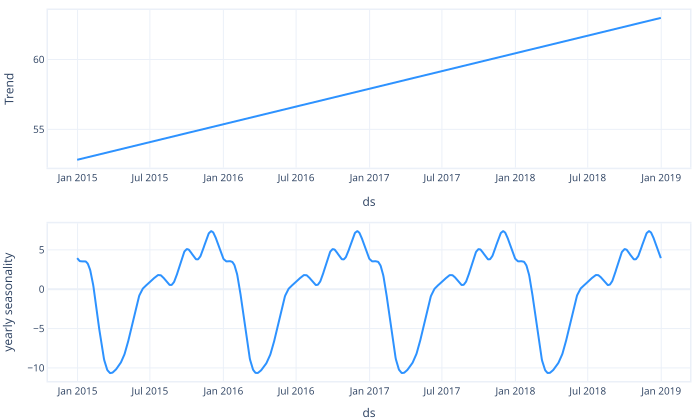

In [8]:
m.plot_components(forecast)

函数 `plot_paramters` 和 `plot_components` 指定要绘制的组件。因此，对于下一个可视化，我们将仅关注季节性（分别不显示趋势）。

可视化季节性的另一种方法是使用 `plot_paramters` 绘制模型参数。在下面的可视化中，季节性的贡献仅显示一个时期，这里是一年的季节性。

WARNING - (py.warnings._showwarnmsg) - d:\Neural_Networks\envs\timeseries\Lib\site-packages\neuralprophet\plot_model_parameters_plotly.py:475: FutureWarning:

The behavior of DatetimeProperties.to_pydatetime is deprecated, in a future version this will return a Series containing python datetime objects instead of an ndarray. To retain the old behavior, call `np.array` on the result


WARNING - (py.warnings._showwarnmsg) - d:\Neural_Networks\envs\timeseries\Lib\site-packages\neuralprophet\plot_model_parameters_plotly.py:508: FutureWarning:

The behavior of DatetimeProperties.to_pydatetime is deprecated, in a future version this will return a Series containing python datetime objects instead of an ndarray. To retain the old behavior, call `np.array` on the result




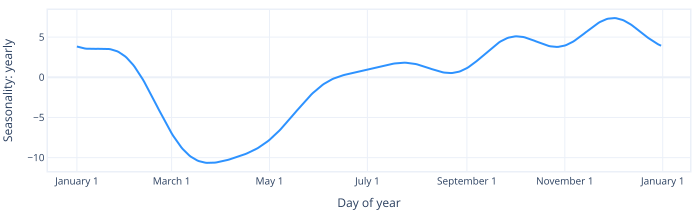

In [9]:
m.plot_parameters(components=["seasonality"])

NeuralProphet 中的季节性是借助傅立叶项建模的。您可以将傅立叶项视为具有不同周期和幅度的多个正弦和余弦函数的总和。这样，NeuralProphet 就可以对多个季节性进行建模。季节性可以是任意周期（长度），例如具有每日数据 ($p = 365.25$) 或每周数据的年度季节性 ($p = 52.18$)。

您可以在 NeuralProphet 模型部分下的 [维基百科上的傅立叶项](https://en.wikipedia.org/wiki/Fourier_series) 和 [关于 NeuralProphet 的论文](https://arxiv.org/abs/2001.04063) 中阅读更多关于季节性的详细内部运作的信息。

默认情况下，如果数据频率高于相应季节性，并且训练数据中包含两个完整的季节性周期，则会自动启用“年度”、“每周”和“每日”季节性。例如，如果数据分辨率为小时，并且至少记录了两天，则会自动启用“每日”季节性。

我们继续手动启用“年度”、“每周”和“每日”季节性，看看效果如何。

WARNING - (NP.forecaster.fit) - When Global modeling with local normalization, metrics are displayed in normalized scale.
WARNING - (py.warnings._showwarnmsg) - d:\Neural_Networks\envs\timeseries\Lib\site-packages\neuralprophet\df_utils.py:1152: FutureWarning:

Series.view is deprecated and will be removed in a future version. Use ``astype`` as an alternative to change the dtype.


INFO - (NP.df_utils._infer_frequency) - Major frequency D corresponds to 99.932% of the data.
INFO - (NP.df_utils._infer_frequency) - Dataframe freq automatically defined as D
INFO - (NP.config.init_data_params) - Setting normalization to global as only one dataframe provided for training.
INFO - (NP.config.set_auto_batch_epoch) - Auto-set batch_size to 32
INFO - (NP.config.set_auto_batch_epoch) - Auto-set epochs to 100


Training: |          | 0/? [00:00<?, ?it/s]

WARNING - (NP.config.set_lr_finder_args) - Learning rate finder: The number of batches (46) is too small than the required number                     for the learning rate finder (229). The results might not be optimal.
Finding best initial lr: 100%|██████████| 229/229 [00:01<00:00, 125.36it/s]


Training: |          | 0/? [00:34<?, ?it/s, v_num=20, train_loss=0.029, reg_loss=0.000, MAE=7.800, RMSE=9.830, Loss=0.0291, RegLoss=0.000] 

WARNING - (py.warnings._showwarnmsg) - d:\Neural_Networks\envs\timeseries\Lib\site-packages\neuralprophet\df_utils.py:1152: FutureWarning:

Series.view is deprecated and will be removed in a future version. Use ``astype`` as an alternative to change the dtype.


INFO - (NP.df_utils._infer_frequency) - Major frequency D corresponds to 99.932% of the data.
WARNING - (py.warnings._showwarnmsg) - d:\Neural_Networks\envs\timeseries\Lib\site-packages\neuralprophet\df_utils.py:1152: FutureWarning:

Series.view is deprecated and will be removed in a future version. Use ``astype`` as an alternative to change the dtype.


WARNING - (py.warnings._showwarnmsg) - d:\Neural_Networks\envs\timeseries\Lib\site-packages\neuralprophet\df_utils.py:1152: FutureWarning:

Series.view is deprecated and will be removed in a future version. Use ``astype`` as an alternative to change the dtype.


INFO - (NP.df_utils._infer_frequency) - Defined frequency is equal to major frequency - D
WARNING - (py.warnings._sho


Predicting DataLoader 0: 100%|██████████| 2/2 [00:00<00:00, 201.15it/s]

INFO - (NP.df_utils.return_df_in_original_format) - Returning df with no ID column
WARNING - (py.warnings._showwarnmsg) - d:\Neural_Networks\envs\timeseries\Lib\site-packages\neuralprophet\plot_forecast_plotly.py:100: FutureWarning:

The behavior of DatetimeProperties.to_pydatetime is deprecated, in a future version this will return a Series containing python datetime objects instead of an ndarray. To retain the old behavior, call `np.array` on the result




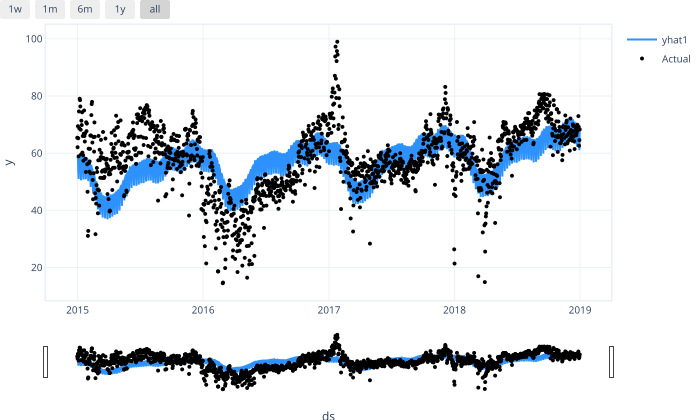

In [10]:
# Model and prediction
m = NeuralProphet(
    # Disable trend changepoints
    n_changepoints=0,
    # Enable all seasonality components
    yearly_seasonality=True,
    weekly_seasonality=True,
    daily_seasonality=True,
)
m.set_plotting_backend("plotly-static")
metrics = m.fit(df)
forecast = m.predict(df)
m.plot(forecast)

WARNING - (py.warnings._showwarnmsg) - d:\Neural_Networks\envs\timeseries\Lib\site-packages\neuralprophet\plot_forecast_plotly.py:410: FutureWarning:

The behavior of DatetimeProperties.to_pydatetime is deprecated, in a future version this will return a Series containing python datetime objects instead of an ndarray. To retain the old behavior, call `np.array` on the result




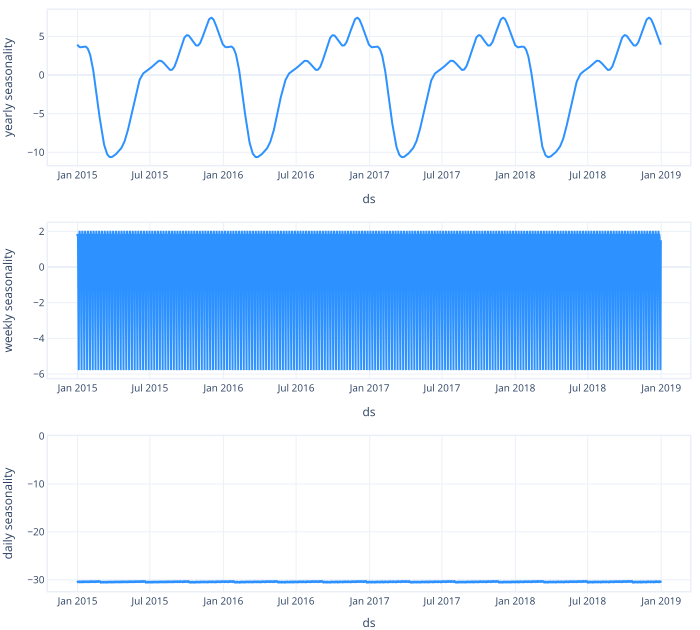

In [11]:
m.plot_components(forecast, components=["seasonality"])

绘制这三个季节性时，我们可以看到每日季节性呈一条平线。这是意料之中的，因为数据是每日的，因此没有日内差异。

对于每周季节性，我们可以放大或使用`plot_parameters`绘制单个时期。

WARNING - (py.warnings._showwarnmsg) - d:\Neural_Networks\envs\timeseries\Lib\site-packages\neuralprophet\plot_model_parameters_plotly.py:475: FutureWarning:

The behavior of DatetimeProperties.to_pydatetime is deprecated, in a future version this will return a Series containing python datetime objects instead of an ndarray. To retain the old behavior, call `np.array` on the result


WARNING - (py.warnings._showwarnmsg) - d:\Neural_Networks\envs\timeseries\Lib\site-packages\neuralprophet\plot_model_parameters_plotly.py:508: FutureWarning:

The behavior of DatetimeProperties.to_pydatetime is deprecated, in a future version this will return a Series containing python datetime objects instead of an ndarray. To retain the old behavior, call `np.array` on the result


WARNING - (py.warnings._showwarnmsg) - d:\Neural_Networks\envs\timeseries\Lib\site-packages\neuralprophet\plot_model_parameters_plotly.py:564: FutureWarning:

'H' is deprecated and will be removed in a future version, please u

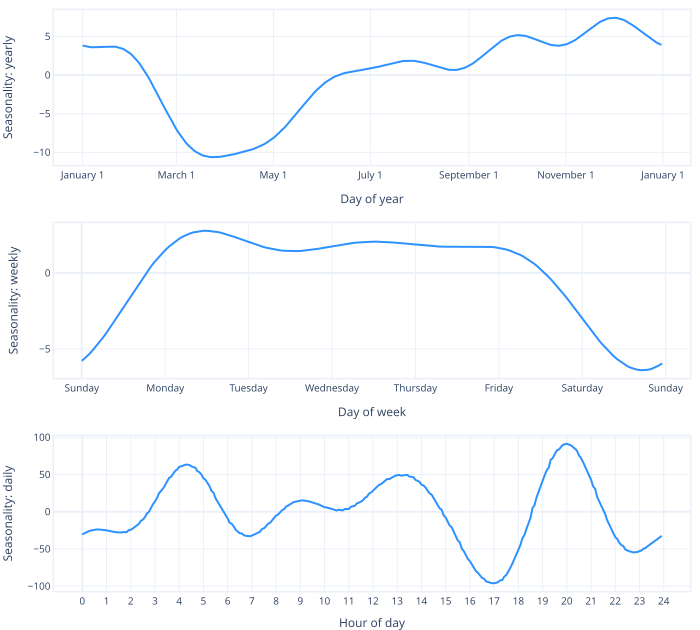

In [12]:
m.plot_parameters(components=["seasonality"])

注意：每日季节性的模式是纯噪声，因为它没有可供拟合的日内数据。这是傅立叶项方法的一个限制：虽然我们能够拟合连续季节性，但观察样本之间的周期可能会过度拟合。这可以通过禁用季节性或将其设置为较少数量的傅立叶项来解决，从而降低其复杂性。

In [13]:
metrics

,train_loss,reg_loss,MAE,RMSE,Loss,RegLoss,epoch
0,1.136607,0.0,101.593666,121.161179,1.137446,0.0,0
1,0.784193,0.0,72.998909,92.958366,0.785262,0.0,1
2,0.543194,0.0,52.903141,69.577217,0.542882,0.0,2
3,0.404328,0.0,41.068310,53.761810,0.403523,0.0,3
4,0.297574,0.0,32.084869,42.213573,0.297948,0.0,4
...,...,...,...,...,...,...,...
95,0.029031,0.0,7.806018,9.839596,0.029181,0.0,95
96,0.029023,0.0,7.769255,9.785789,0.028941,0.0,96
97,0.029001,0.0,7.790382,9.799196,0.028996,0.0,97
98,0.029009,0.0,7.780581,9.763766,0.028982,0.0,98
